In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
dfv=pd.read_csv(r'..\..\Data\INE\clean_viajeros_07_04_2026.csv')

In [64]:
dfp=pd.read_csv(r'..\..\Data\INE\clean_pernoctaciones_07_04_2026.csv')

In [65]:
dfv

,ccaa,pais_origen,mes,qty_viajeros,año
0,Andalucia,Residentes en España,Enero,435583.00,2015
1,Andalucia,Residentes en España,Febrero,592854.00,2015
2,Andalucia,Residentes en España,Marzo,671180.00,2015
3,Andalucia,Residentes en España,Abril,769073.00,2015
4,Andalucia,Residentes en España,Mayo,812986.00,2015
...,...,...,...,...,...
6895,Madrid,Países africanos,Agosto,11537.00,2019
6896,Madrid,Países africanos,Septiembre,10427.00,2019
6897,Madrid,Países africanos,Octubre,12293.00,2019
6898,Madrid,Países africanos,Noviembre,12779.00,2019


In [66]:
dfp

,ccaa,pais_origen,mes,qty_pernoctaciones,año
0,Andalucia,Residentes en España,Enero,902311.00,2015
1,Andalucia,Residentes en España,Febrero,1255482.00,2015
2,Andalucia,Residentes en España,Marzo,1644221.00,2015
3,Andalucia,Residentes en España,Abril,1900705.00,2015
4,Andalucia,Residentes en España,Mayo,1711168.00,2015
...,...,...,...,...,...
6895,Madrid,Países africanos,Agosto,29715.00,2019
6896,Madrid,Países africanos,Septiembre,31773.00,2019
6897,Madrid,Países africanos,Octubre,34520.00,2019
6898,Madrid,Países africanos,Noviembre,36234.00,2019


In [67]:
# Volumen total de viajeros y pernoctaciones por año

dfp_totales = dfp.groupby(["ccaa","año"])[['qty_pernoctaciones']].sum().reset_index()
dfv_totales = dfv.groupby(["ccaa","año"])[['qty_viajeros']].sum().reset_index()

df_totales = pd.merge(dfp_totales, dfv_totales, on=['ccaa', 'año'], how='inner')
df_totales

,ccaa,año,qty_pernoctaciones,qty_viajeros
0,Andalucia,2015,44754444.00,15155695.00
1,Andalucia,2016,48274832.00,16195488.00
2,Andalucia,2017,48679522.00,16407001.00
3,Andalucia,2018,49376645.00,16780940.00
4,Andalucia,2019,50559099.00,17675746.00
5,Cataluña,2015,45716599.00,15527731.00
6,Cataluña,2016,48592590.00,16637047.00
7,Cataluña,2017,49544938.00,17029251.00
8,Cataluña,2018,48626481.00,17086891.00
9,Cataluña,2019,49076635.00,17419561.00


In [68]:
dfp_total_mensual = dfp.groupby(['ccaa', 'año', 'mes'])['qty_pernoctaciones'].sum().reset_index()

dfp_medias = dfp_total_mensual.groupby('ccaa')['qty_pernoctaciones'].mean().reset_index().round(2).sort_values('qty_pernoctaciones', ascending=False)

display(dfp_medias)

,ccaa,qty_pernoctaciones
3,Islas Baleares,4682483.38
0,Andalucia,4027409.03
1,Cataluña,4025954.05
2,Comunidad Valenciana,2276701.37
4,Madrid,1524242.97


In [69]:
dfv_total_mensual = dfv.groupby(['ccaa', 'año', 'mes'])['qty_viajeros'].sum().reset_index()

dfv_medias = dfv_total_mensual.groupby('ccaa')['qty_viajeros'].mean().reset_index().round(2).sort_values('qty_viajeros', ascending=False)

display(dfv_medias)

,ccaa,qty_viajeros
1,Cataluña,1395008.02
0,Andalucia,1370247.83
4,Madrid,804746.03
3,Islas Baleares,795699.80
2,Comunidad Valenciana,666946.70


In [70]:
dfmedias=pd.merge(dfv_medias,dfp_medias,on='ccaa',how='inner')

dfmedias['Media_per_capita']=round(dfmedias['qty_pernoctaciones'] / dfmedias['qty_viajeros'],2)

display(dfmedias)

,ccaa,qty_viajeros,qty_pernoctaciones,Media_per_capita
0,Cataluña,1395008.02,4025954.05,2.89
1,Andalucia,1370247.83,4027409.03,2.94
2,Madrid,804746.03,1524242.97,1.89
3,Islas Baleares,795699.80,4682483.38,5.88
4,Comunidad Valenciana,666946.70,2276701.37,3.41


In [71]:
df_mediasaño = df_totales.copy()
df_mediasaño['qty_pernoctaciones']  = df_mediasaño['qty_pernoctaciones'] / 12
df_mediasaño['qty_viajeros']  = df_mediasaño['qty_viajeros'] / 12

In [72]:
# esto muestra la media mensual por año

pd.options.display.float_format = '{:.2f}'.format
df_mediasaño

,ccaa,año,qty_pernoctaciones,qty_viajeros
0,Andalucia,2015,3729537.00,1262974.58
1,Andalucia,2016,4022902.67,1349624.00
2,Andalucia,2017,4056626.83,1367250.08
3,Andalucia,2018,4114720.42,1398411.67
4,Andalucia,2019,4213258.25,1472978.83
5,Cataluña,2015,3809716.58,1293977.58
6,Cataluña,2016,4049382.50,1386420.58
7,Cataluña,2017,4128744.83,1419104.25
8,Cataluña,2018,4052206.75,1423907.58
9,Cataluña,2019,4089719.58,1451630.08


In [73]:
df_mediasaño['Media_per_capita']=round(df_mediasaño['qty_pernoctaciones'] / df_mediasaño['qty_viajeros'],2)

display(df_mediasaño)

,ccaa,año,qty_pernoctaciones,qty_viajeros,Media_per_capita
0,Andalucia,2015,3729537.00,1262974.58,2.95
1,Andalucia,2016,4022902.67,1349624.00,2.98
2,Andalucia,2017,4056626.83,1367250.08,2.97
3,Andalucia,2018,4114720.42,1398411.67,2.94
4,Andalucia,2019,4213258.25,1472978.83,2.86
5,Cataluña,2015,3809716.58,1293977.58,2.94
6,Cataluña,2016,4049382.50,1386420.58,2.92
7,Cataluña,2017,4128744.83,1419104.25,2.91
8,Cataluña,2018,4052206.75,1423907.58,2.85
9,Cataluña,2019,4089719.58,1451630.08,2.82


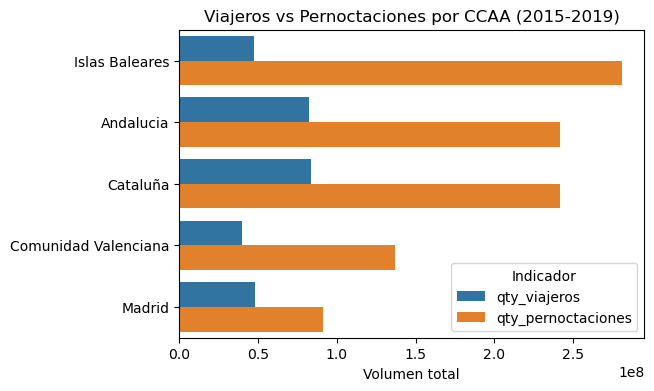

In [74]:
# Acumulado por CCAA
df_ccaa = (
    df_totales
    .groupby('ccaa')[['qty_viajeros', 'qty_pernoctaciones']]
    .sum()
    .sort_values('qty_pernoctaciones', ascending=False)
    .reset_index()
)

df_plot = df_ccaa.melt(
    id_vars='ccaa',
    value_vars=['qty_viajeros', 'qty_pernoctaciones'],
    var_name='tipo',
    value_name='valor'
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=df_plot,
    y='ccaa',
    x='valor',
    hue='tipo'
)

plt.title('Viajeros vs Pernoctaciones por CCAA (2015-2019)')
plt.xlabel('Volumen total')
plt.ylabel('')
plt.legend(title='Indicador')

plt.show()

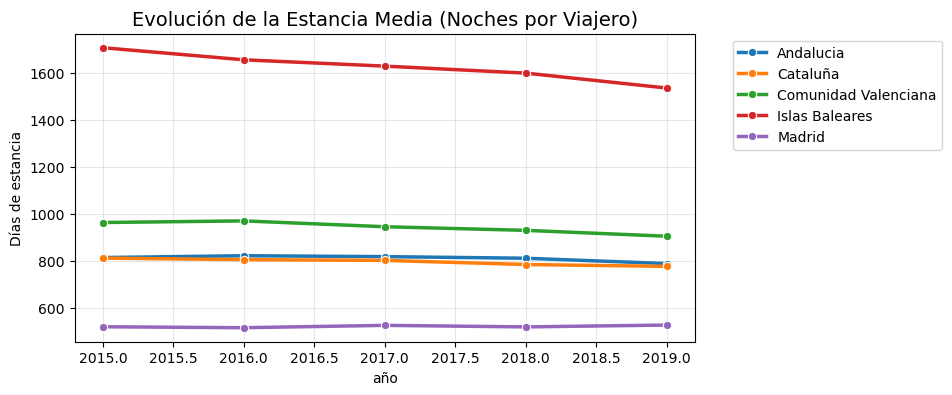

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.lineplot(data=dfmedias_año, x='año', y='Media_per_capita', hue='ccaa', marker='o', linewidth=2.5)

plt.title('Evolución de la Estancia Media (Noches por Viajero)', fontsize=14)
plt.ylabel('Días de estancia')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

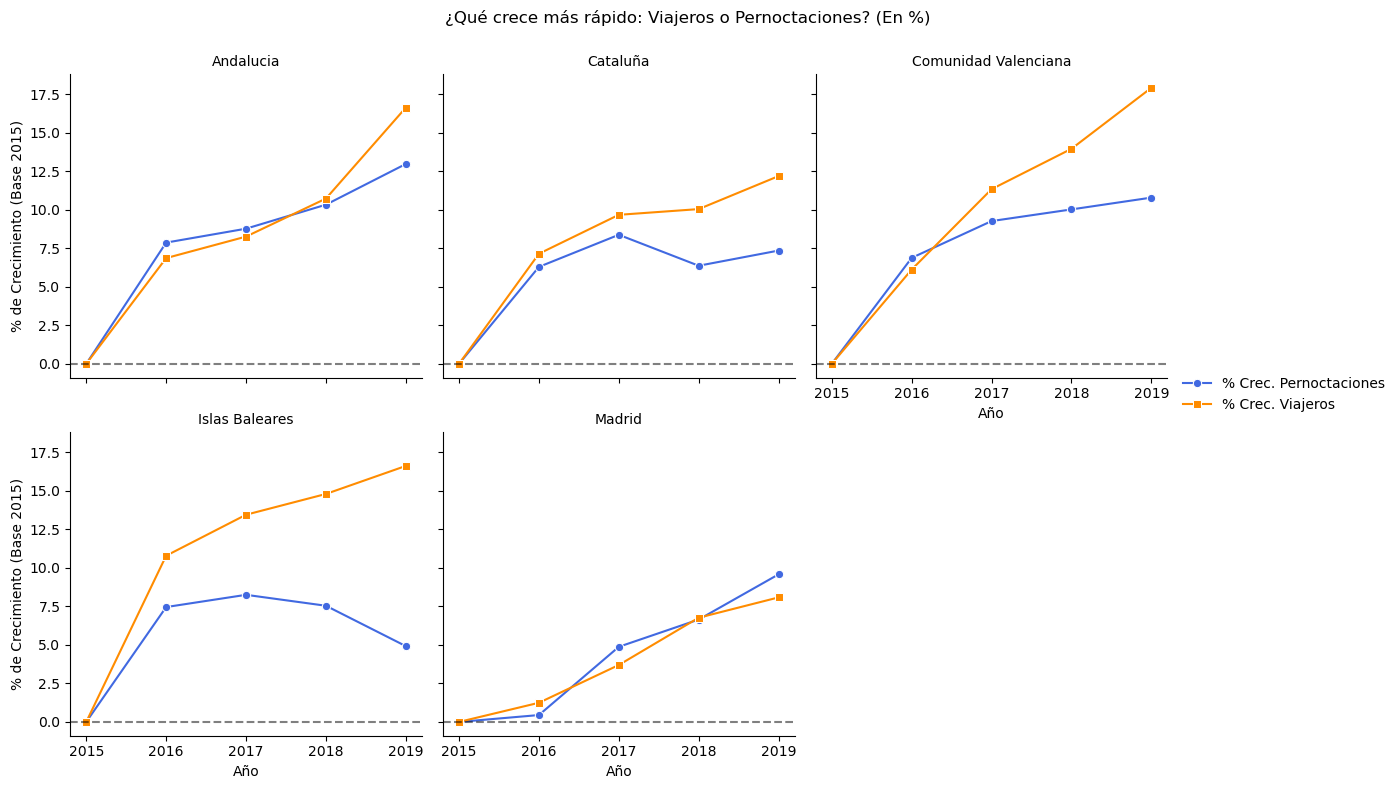

In [76]:
# Grafico de crecimiento relativo

# 1. Creamos las columnas de crecimiento porcentual respecto a 2015 por cada CCAA
dfmedias_año['pct_viajeros'] = dfmedias_año.groupby('ccaa')['qty_viajeros'].transform(lambda x: (x / x.iloc[0] - 1) * 100)
dfmedias_año['pct_pernoctaciones'] = dfmedias_año.groupby('ccaa')['qty_pernoctaciones'].transform(lambda x: (x / x.iloc[0] - 1) * 100)

# 2. Reutilizamos tu estructura de FacetGrid que tanto te ha gustado
g = sns.FacetGrid(dfmedias_año, col="ccaa", col_wrap=3, height=4)

# Dibujamos las dos líneas de porcentaje
g.map(sns.lineplot, "año", "pct_pernoctaciones", marker="o", color="royalblue", label="% Crec. Pernoctaciones")
g.map(sns.lineplot, "año", "pct_viajeros", marker="s", color="darkorange", label="% Crec. Viajeros")

# Añadimos una línea horizontal en el 0 para que se vea claro el punto de partida
g.map(plt.axhline, y=0, color='black', ls='--', alpha=0.5)

g.add_legend()
g.set_axis_labels("Año", "% de Crecimiento (Base 2015)")
g.set_titles("{col_name}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('¿Qué crece más rápido: Viajeros o Pernoctaciones? (En %)')
plt.show()